In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Reading the Evaluation data by Pathologist

In [2]:
evaluator_id = 'evaluator3'
eval_data_path = f"input/{evaluator_id}/pathopen_image_augmentation_eval_data.csv"
eval_data = pd.read_csv(eval_data_path)
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,Evaluation Image_Augmentation\n(Benchmark 4),Unnamed: 6,OE_Question_2,OE_Correct_Answer_2,Evaluation Image_Augmentation\n(Benchmark 4).1,Unnamed: 10
0,NaN,NaN,NaN,NaN,NaN,Clinical Relevance,Visual Grounding,NaN,NaN,Clinical Relevance,Visual Grounding
1,36.0,img_pathopen_36_01_aug_0.png,https://drive.google.com/file/d/1cMoJ2ek22BqRA...,What genetic factors are associated with the d...,HLA class II genes HLA DQ2 and HLA DQ8 on chro...,2,2,What are the three classic histopathologic fin...,"Increased intraepithelial T lymphocytes (IEL),...",2,2
2,112.0,img_pathopen_112_01_aug_2.png,https://drive.google.com/file/d/1SeSyToKBJ5v-7...,What is the disease process depicted in the up...,The upper part of this image shows confluent u...,2,2,How would one describe the neoplastic componen...,"There is an infiltrative, irregular neoplasm c...",2,2
3,128.0,img_pathopen_128_01_aug_2.png,https://drive.google.com/file/d/1HfYg4BjUhNamN...,The thick bands of collagen depicted in this i...,The classic pattern of thick ropey collagen in...,2,2,What is the predominant inflammatory cell type...,The predominant inflammatory cell type present...,2,2
4,152.0,img_pathopen_152_03_aug_2.png,https://drive.google.com/file/d/1QLDBTUjxXRBmb...,What is the description of the abnormal cells ...,The abnormal cells in this image are large cel...,2,2,What is the most likely diagnosis based on thi...,In the setting of CD30 expression by the abnor...,2,2


Creating the directory structure to save Graphs and Output for Each Evaluator

In [3]:
output_data_path = f"output/{evaluator_id}"
os.makedirs(output_data_path, exist_ok=True)

Renaming some columns

In [4]:
eval_data = eval_data.rename(columns={'Evaluation Image_Augmentation\n(Benchmark 4)': 'OE_Image_Augmentation_1_Clin_Relv',
                                        'Unnamed: 6': 'OE_Image_Augmentation_1_Vis_Ground',
                                        'Evaluation Image_Augmentation\n(Benchmark 4).1': 'OE_Image_Augmentation_2_Clin_Relv',
                                        'Unnamed: 10': 'OE_Image_Augmentation_2_Vis_Ground',
                                        })

eval_data = eval_data.drop(index=0) #dropping the first row which contains the benchmark names
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question_1,OE_Correct_Answer_1,OE_Image_Augmentation_1_Clin_Relv,OE_Image_Augmentation_1_Vis_Ground,OE_Question_2,OE_Correct_Answer_2,OE_Image_Augmentation_2_Clin_Relv,OE_Image_Augmentation_2_Vis_Ground
1,36.0,img_pathopen_36_01_aug_0.png,https://drive.google.com/file/d/1cMoJ2ek22BqRA...,What genetic factors are associated with the d...,HLA class II genes HLA DQ2 and HLA DQ8 on chro...,2,2,What are the three classic histopathologic fin...,"Increased intraepithelial T lymphocytes (IEL),...",2,2
2,112.0,img_pathopen_112_01_aug_2.png,https://drive.google.com/file/d/1SeSyToKBJ5v-7...,What is the disease process depicted in the up...,The upper part of this image shows confluent u...,2,2,How would one describe the neoplastic componen...,"There is an infiltrative, irregular neoplasm c...",2,2
3,128.0,img_pathopen_128_01_aug_2.png,https://drive.google.com/file/d/1HfYg4BjUhNamN...,The thick bands of collagen depicted in this i...,The classic pattern of thick ropey collagen in...,2,2,What is the predominant inflammatory cell type...,The predominant inflammatory cell type present...,2,2
4,152.0,img_pathopen_152_03_aug_2.png,https://drive.google.com/file/d/1QLDBTUjxXRBmb...,What is the description of the abnormal cells ...,The abnormal cells in this image are large cel...,2,2,What is the most likely diagnosis based on thi...,In the setting of CD30 expression by the abnor...,2,2
5,21.0,img_pathopen_21_01_aug_1.png,https://drive.google.com/file/d/1-Mtf1BSxm_BO7...,In an overweight adolescent with mildly increa...,"In the background of steatosis, there is incre...",2,2,NaN,NaN,NaN,NaN


Converting all the evaluation columns from Str to Int

In [5]:
eval_data = eval_data.astype({'OE_Image_Augmentation_1_Clin_Relv': 'float',
                                'OE_Image_Augmentation_1_Vis_Ground': 'float',
                                'OE_Image_Augmentation_2_Clin_Relv': 'float',
                                'OE_Image_Augmentation_2_Vis_Ground': 'float',
                                })

eval_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 34 entries, 1 to 34
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   CASE_ID                             34 non-null     float64
 1   Image_ID                            34 non-null     str    
 2   Image_URL                           34 non-null     str    
 3   OE_Question_1                       34 non-null     str    
 4   OE_Correct_Answer_1                 34 non-null     str    
 5   OE_Image_Augmentation_1_Clin_Relv   34 non-null     float64
 6   OE_Image_Augmentation_1_Vis_Ground  34 non-null     float64
 7   OE_Question_2                       33 non-null     str    
 8   OE_Correct_Answer_2                 33 non-null     str    
 9   OE_Image_Augmentation_2_Clin_Relv   33 non-null     float64
 10  OE_Image_Augmentation_2_Vis_Ground  33 non-null     float64
dtypes: float64(5), str(6)
memory usage: 3.1 KB


Finding Missing Evaluations or Wrong Evaluations

In [6]:
OE_Correct_Answer_1_Clin_Relv_Missing = eval_data[(eval_data['OE_Question_1'].notnull()) & (eval_data['OE_Correct_Answer_1'].notnull()) & ((eval_data['OE_Image_Augmentation_1_Clin_Relv'].isnull()) | (~eval_data['OE_Image_Augmentation_1_Clin_Relv'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_1_Vis_Ground_Missing = eval_data[(eval_data['OE_Question_1'].notnull()) & (eval_data['OE_Correct_Answer_1'].notnull()) & ((eval_data['OE_Image_Augmentation_1_Vis_Ground'].isnull()) | (~eval_data['OE_Image_Augmentation_1_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Clin_Relv_Missing = eval_data[(eval_data['OE_Question_2'].notnull()) & (eval_data['OE_Correct_Answer_2'].notnull()) & ((eval_data['OE_Image_Augmentation_2_Clin_Relv'].isnull()) | (~eval_data['OE_Image_Augmentation_2_Clin_Relv'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_2_Vis_Ground_Missing = eval_data[(eval_data['OE_Question_2'].notnull()) & (eval_data['OE_Correct_Answer_2'].notnull()) & ((eval_data['OE_Image_Augmentation_2_Vis_Ground'].isnull()) | (~eval_data['OE_Image_Augmentation_2_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()

print(f"OE_Correct_Answer_1_Clin_Relv_Missing: {OE_Correct_Answer_1_Clin_Relv_Missing}")
print(f"OE_Correct_Answer_1_Vis_Ground_Missing: {OE_Correct_Answer_1_Vis_Ground_Missing}")
print(f"OE_Correct_Answer_2_Clin_Relv_Missing: {OE_Correct_Answer_2_Clin_Relv_Missing}")
print(f"OE_Correct_Answer_2_Vis_Ground_Missing: {OE_Correct_Answer_2_Vis_Ground_Missing}")

OE_Correct_Answer_1_Clin_Relv_Missing: []
OE_Correct_Answer_1_Vis_Ground_Missing: []
OE_Correct_Answer_2_Clin_Relv_Missing: []
OE_Correct_Answer_2_Vis_Ground_Missing: []


#### Correct Answer

1

In [7]:
oe_correct_answer_1_clin_relv_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Image_Augmentation_1_Clin_Relv'].notnull()]
oe_correct_answer_1_clin_relv_total = len(oe_correct_answer_1_clin_relv_df)
oe_correct_answer_1_clin_relv_eval_2 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == 2])
oe_correct_answer_1_clin_relv_eval_1 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == 1])
oe_correct_answer_1_clin_relv_eval_0 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == 0])
oe_correct_answer_1_clin_relv_eval_neg_1 = len(oe_correct_answer_1_clin_relv_df[oe_correct_answer_1_clin_relv_df['OE_Image_Augmentation_1_Clin_Relv'] == -1])

In [8]:
oe_correct_answer_1_vis_ground_df = eval_data[eval_data['OE_Question_1'].notnull() & eval_data['OE_Correct_Answer_1'].notnull() & eval_data['OE_Image_Augmentation_1_Vis_Ground'].notnull()]
oe_correct_answer_1_vis_ground_total = len(oe_correct_answer_1_vis_ground_df)
oe_correct_answer_1_vis_ground_eval_2 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == 2])
oe_correct_answer_1_vis_ground_eval_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == 1])
oe_correct_answer_1_vis_ground_eval_0 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == 0])
oe_correct_answer_1_vis_ground_eval_neg_1 = len(oe_correct_answer_1_vis_ground_df[oe_correct_answer_1_vis_ground_df['OE_Image_Augmentation_1_Vis_Ground'] == -1])


2

In [9]:
oe_correct_answer_2_clin_relv_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Image_Augmentation_2_Clin_Relv'].notnull()]
oe_correct_answer_2_clin_relv_total = len(oe_correct_answer_2_clin_relv_df)
oe_correct_answer_2_clin_relv_eval_2 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == 2])
oe_correct_answer_2_clin_relv_eval_1 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == 1])
oe_correct_answer_2_clin_relv_eval_0 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == 0])
oe_correct_answer_2_clin_relv_eval_neg_1 = len(oe_correct_answer_2_clin_relv_df[oe_correct_answer_2_clin_relv_df['OE_Image_Augmentation_2_Clin_Relv'] == -1])

In [10]:
oe_correct_answer_2_vis_ground_df = eval_data[eval_data['OE_Question_2'].notnull() & eval_data['OE_Correct_Answer_2'].notnull() & eval_data['OE_Image_Augmentation_2_Vis_Ground'].notnull()]
oe_correct_answer_2_vis_ground_total = len(oe_correct_answer_2_vis_ground_df)
oe_correct_answer_2_vis_ground_eval_2 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == 2])
oe_correct_answer_2_vis_ground_eval_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == 1])
oe_correct_answer_2_vis_ground_eval_0 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == 0])
oe_correct_answer_2_vis_ground_eval_neg_1 = len(oe_correct_answer_2_vis_ground_df[oe_correct_answer_2_vis_ground_df['OE_Image_Augmentation_2_Vis_Ground'] == -1])

Calculating the consolidated information all the correct questions/answers

In [11]:
correct_answer_benchmark_label = [
                                    'Clinical Relevance',
                                    'Visual Grounding',
                                ]

correct_answer_total = [oe_correct_answer_1_clin_relv_total + oe_correct_answer_2_clin_relv_total,
                        oe_correct_answer_1_vis_ground_total + oe_correct_answer_2_vis_ground_total
                        ]

correct_answer_eval_2 = [oe_correct_answer_1_clin_relv_eval_2 + oe_correct_answer_2_clin_relv_eval_2,
                        oe_correct_answer_1_vis_ground_eval_2 + oe_correct_answer_2_vis_ground_eval_2,
                        ]

correct_answer_eval_1 = [oe_correct_answer_1_clin_relv_eval_1 + oe_correct_answer_2_clin_relv_eval_1,
                        oe_correct_answer_1_vis_ground_eval_1 + oe_correct_answer_2_vis_ground_eval_1,
                        ]

correct_answer_eval_0 = [oe_correct_answer_1_clin_relv_eval_0 + oe_correct_answer_2_clin_relv_eval_0,
                        oe_correct_answer_1_vis_ground_eval_0 + oe_correct_answer_2_vis_ground_eval_0
                        ]

correct_answer_eval_neg_1 = [oe_correct_answer_1_clin_relv_eval_neg_1 + oe_correct_answer_2_clin_relv_eval_neg_1,
                            oe_correct_answer_1_vis_ground_eval_neg_1 + oe_correct_answer_2_vis_ground_eval_neg_1
                            ]

correct_answer_eval_data = pd.DataFrame({'Total': correct_answer_total,
                                        'Level 2': correct_answer_eval_2,
                                        'Level 1': correct_answer_eval_1,
                                        'Level 0': correct_answer_eval_0,
                                        'Level -1': correct_answer_eval_neg_1}, index=[correct_answer_benchmark_label])

correct_answer_eval_data

,Total,Level 2,Level 1,Level 0,Level -1
Clinical Relevance,67,64,3,0,0
Visual Grounding,67,63,4,0,0


Save the Evaluation Data for correct answers

In [12]:
correct_answer_eval_data.to_pickle(os.path.join(output_data_path, 'pathopen_image_augmentation_correct_answer_eval_data.pkl'))

Open-Ended Image Augmentation Graph

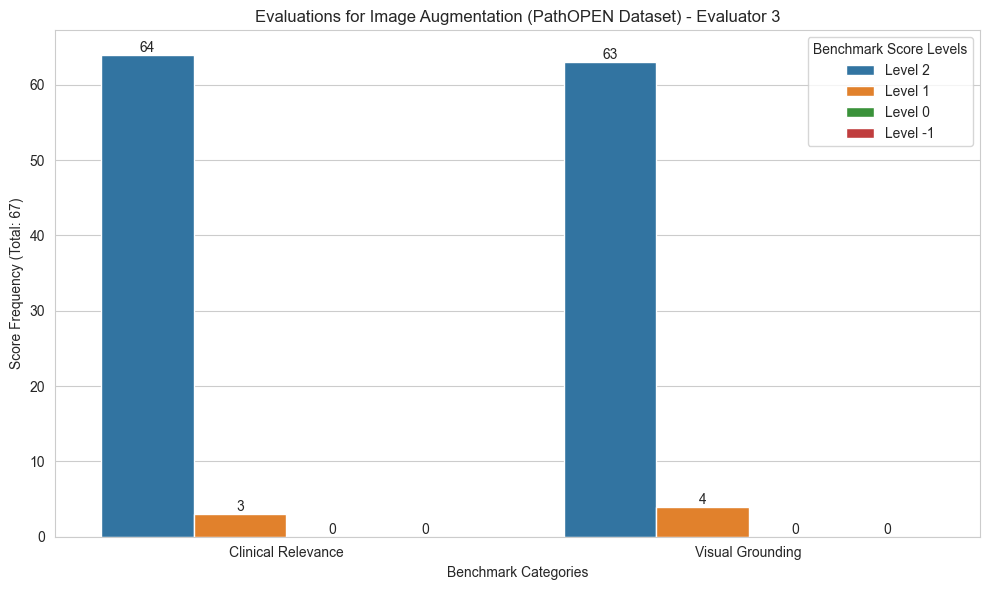

In [13]:
temp_data = correct_answer_eval_data.drop(columns=['Total']).reset_index().melt(id_vars='level_0', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='level_0', y='Values', hue='Column Names')

for container in ax.containers:
    ax.bar_label(container)
    
plt.title(f'Evaluations for Image Augmentation (PathOPEN Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answer_total[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathopen_image_augmentation.png')
plt.show()